# Capítulo 6: Integrales sobre Funciones de una Variable

---

### 6.1. 

---

### 6.2.

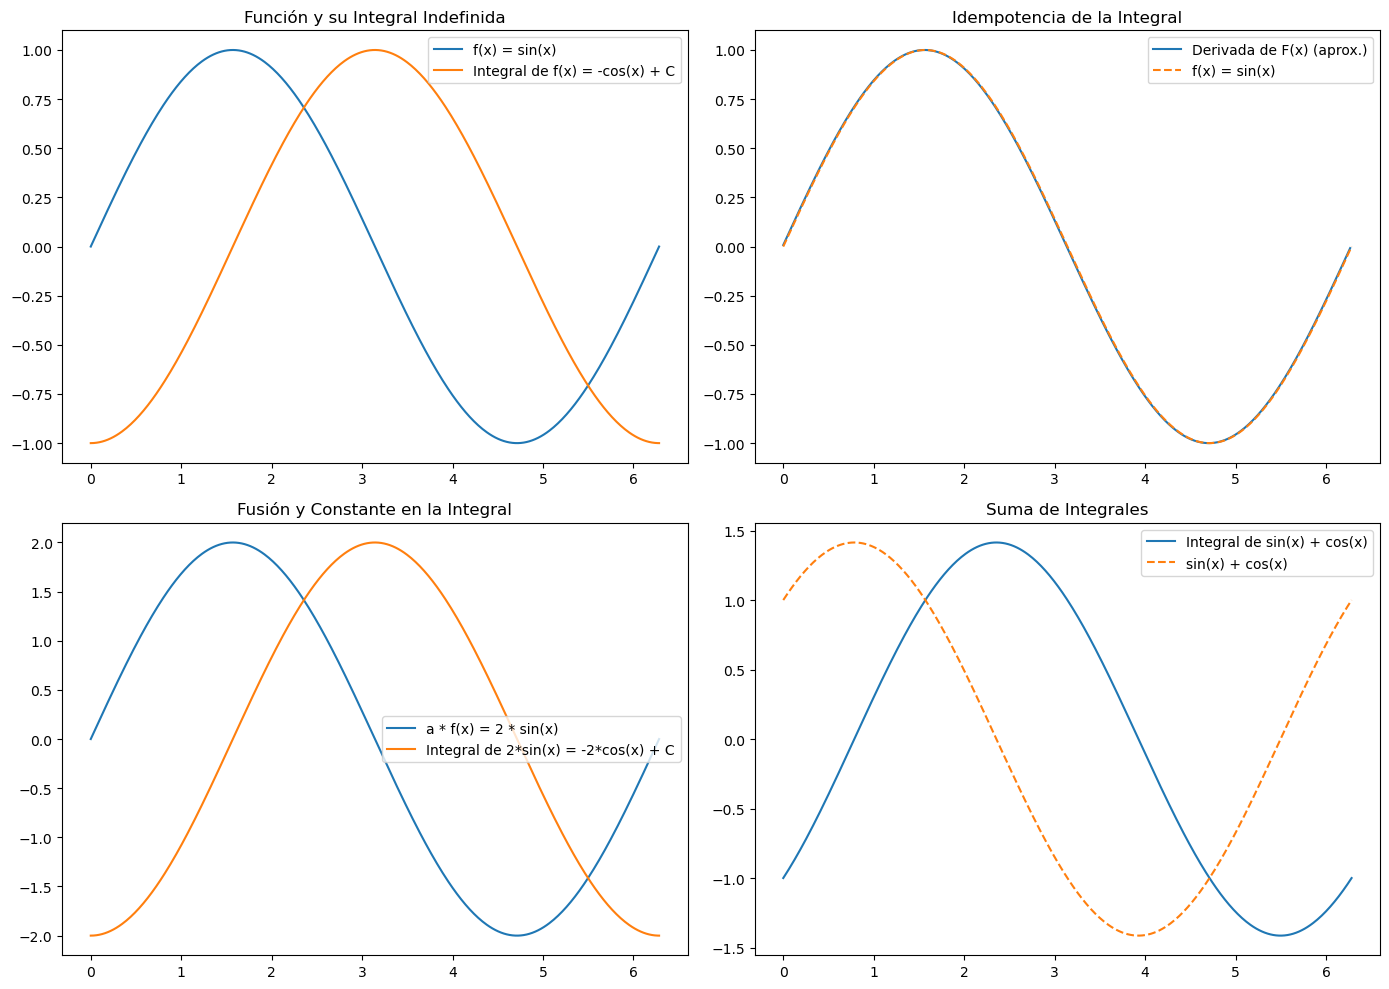

In [1]:
# Ejercicio 1
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Definimos las funciones f(x) = sin(x) y g(x) = cos(x)
def f(x):
    return np.sin(x)
def g(x):
    return np.cos(x)

# Antiderivadas de las funciones
def F(x):
    """Antiderivada de sin(x): integral de sin es -cos"""
    return -np.cos(x)
def G(x):
    """Antiderivada de cos(x): integral de cos es sin"""
    return np.sin(x)

# Dominio para la visualización
x = np.linspace(0, 2 * np.pi, 400)

# Idempotencia y diferencial que anula la integral
f_x = f(x)
F_x = F(x)
dF_x = np.diff(F(x)) / np.diff(x)  # Derivada numérica de F para aproximar f

# Integración de la función constante con f(x)
a = 2  # Constante
af_x = a * f(x)
aF_x = a * F(x)  # Antiderivada de a*f(x)

# Suma de integrales
sum_f_g = f(x) + g(x)
int_sum_f_g = -np.cos(x) + np.sin(x)  # Integral de f(x) + g(x)

# Gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Gráfico de f(x) y su antiderivada F(x)
axes[0, 0].plot(x, f_x, label='f(x) = sin(x)')
axes[0, 0].plot(x, F_x, label='Integral de f(x) = -cos(x) + C')
axes[0, 0].set_title('Función y su Integral Indefinida')
axes[0, 0].legend()

# Gráfico de la derivada de la antiderivada (debe ser f(x))
axes[0, 1].plot(x[:-1], dF_x, label="Derivada de F(x) (aprox.)")
axes[0, 1].plot(x, f_x, label="f(x) = sin(x)", linestyle='dashed')
axes[0, 1].set_title('Idempotencia de la Integral')
axes[0, 1].legend()

# Gráfico de a * f(x) y su integral
axes[1, 0].plot(x, af_x, label='a * f(x) = 2 * sin(x)')
axes[1, 0].plot(x, aF_x, label='Integral de 2*sin(x) = -2*cos(x) + C')
axes[1, 0].set_title('Fusión y Constante en la Integral')
axes[1, 0].legend()

# Gráfico de la suma de integrales
axes[1, 1].plot(x, int_sum_f_g, label='Integral de sin(x) + cos(x)')
axes[1, 1].plot(x, sum_f_g, label='sin(x) + cos(x)', linestyle='dashed')
axes[1, 1].set_title('Suma de Integrales')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

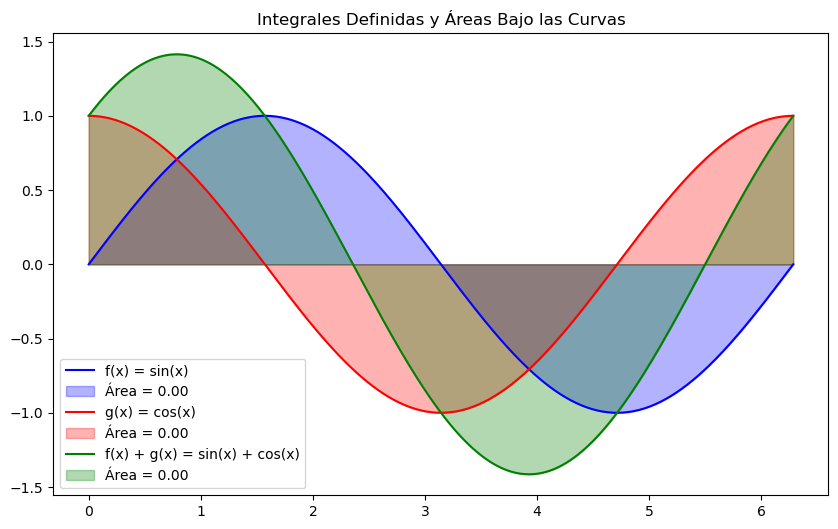

In [2]:
# Ejercicio 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Definimos las funciones f(x) = sin(x) y g(x) = cos(x)
def f(x):
    return np.sin(x)
def g(x):
    return np.cos(x)

# Dominio para la visualización
x = np.linspace(0, 2 * np.pi, 400)

# Integral definida de f(x) = sin(x) de 0 a 2*pi
integral_f, _ = quad(f, 0, 2*np.pi)

# Integral definida de g(x) = cos(x) de 0 a 2*pi
integral_g, _ = quad(g, 0, 2*np.pi)

# Integral definida de la suma f(x) + g(x) de 0 a 2*pi
integral_sum, _ = quad(lambda x: f(x) + g(x), 0, 2*np.pi)

# Preparar datos para gráficos
y_f = f(x)
y_g = g(x)
y_sum = f(x) + g(x)

# Área bajo la curva para visualizar las integrales definidas
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y_f, label='f(x) = sin(x)', color='blue')
ax.fill_between(x, y_f, color='blue', alpha=0.3, label=f'Área = {integral_f:.2f}')
ax.plot(x, y_g, label='g(x) = cos(x)', color='red')
ax.fill_between(x, y_g, color='red', alpha=0.3, label=f'Área = {integral_g:.2f}')
ax.plot(x, y_sum, label='f(x) + g(x) = sin(x) + cos(x)', color='green')
ax.fill_between(x, y_sum, color='green', alpha=0.3, label=f'Área = {integral_sum:.2f}')
ax.set_title('Integrales Definidas y Áreas Bajo las Curvas')
ax.legend()
plt.show()

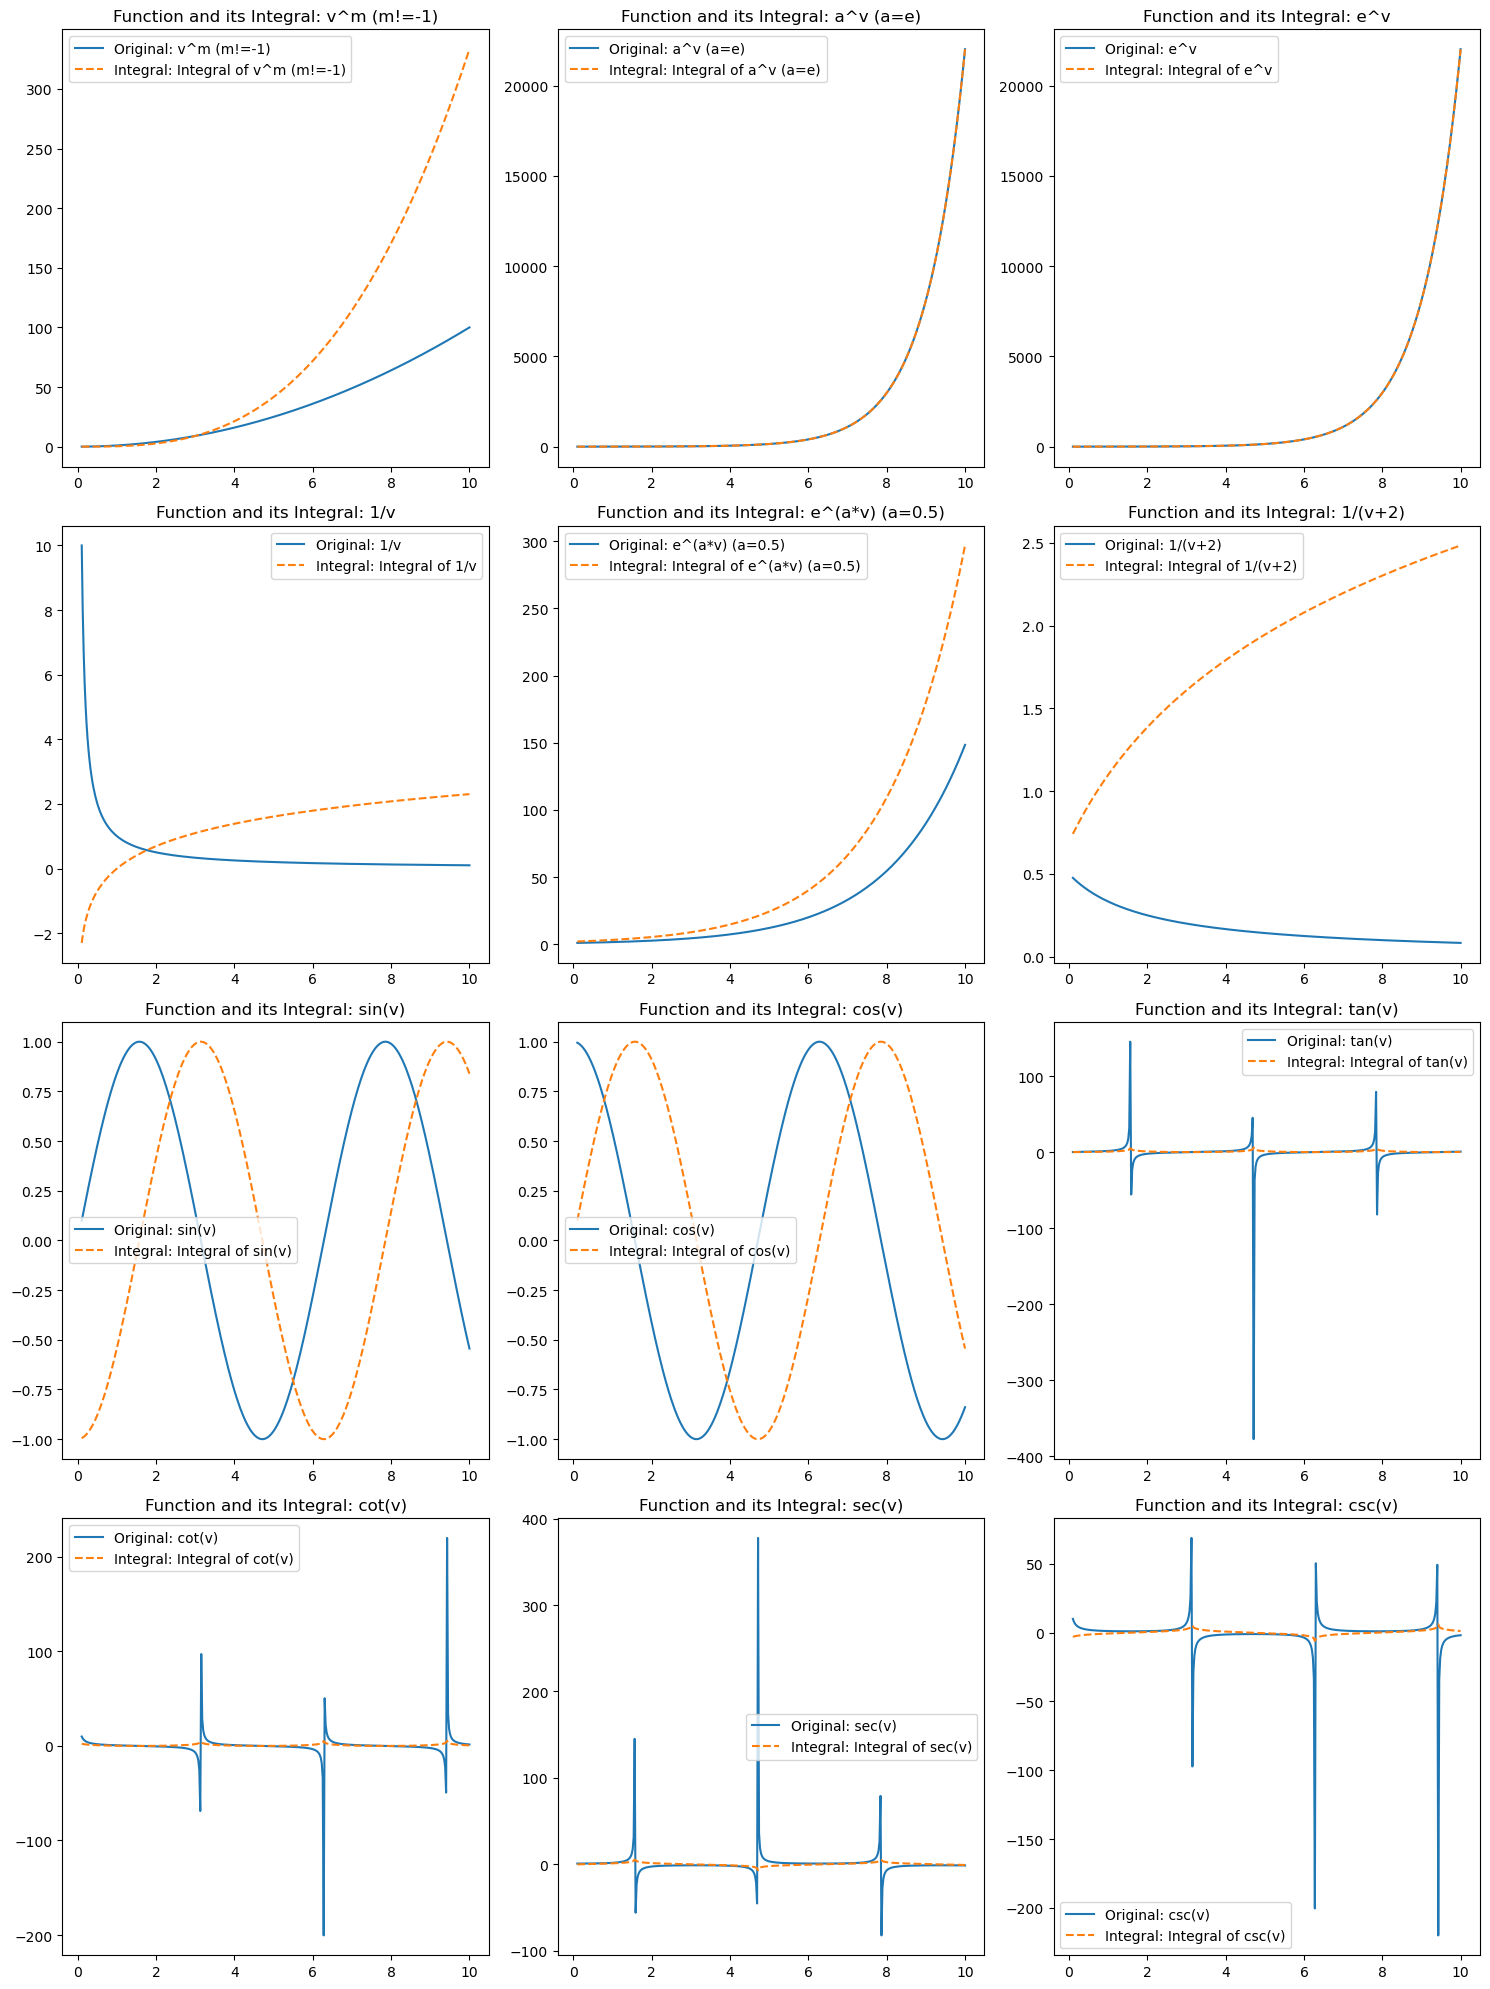

In [33]:
# Ejercicio 3
import numpy as np
import matplotlib.pyplot as plt

# Dominio para las funciones
v = np.linspace(0.1, 10, 400)  # Start at 0.1 to avoid division by zero in log and 1/v

# Funciones y sus integrales
functions = {
    'v^m (m!=-1)': (v**2, v**3 / 3),  # m=2 for example
    'a^v (a=e)': (np.exp(v), np.exp(v)),
    'e^v': (np.exp(v), np.exp(v)),
    '1/v': (1/v, np.log(np.abs(v))),
    'e^(a*v) (a=0.5)': (np.exp(0.5 * v), 2 * np.exp(0.5 * v)),
    '1/(v+2)': (1/(v+2), np.log(np.abs(v+2))),
    'sin(v)': (np.sin(v), -np.cos(v)),
    'cos(v)': (np.cos(v), np.sin(v)),
    'tan(v)': (np.tan(v), -np.log(np.abs(np.cos(v)))),
    'cot(v)': (1/np.tan(v), -np.log(np.abs(np.sin(v)))),
    'sec(v)': (1/np.cos(v), np.log(np.abs(1/np.cos(v) + np.tan(v)))),
    'csc(v)': (1/np.sin(v), np.log(np.abs(1/np.sin(v) - 1/np.tan(v))))
}

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))

for (func, (original, integral)), ax in zip(functions.items(), axes.flatten()):
    ax.plot(v, original, label=f'Original: {func}')
    ax.plot(v, integral, label=f'Integral: Integral of {func}', linestyle='--')
    ax.legend()
    ax.set_title(f'Function and its Integral: {func}')

plt.tight_layout()
plt.show()

### 6.3.

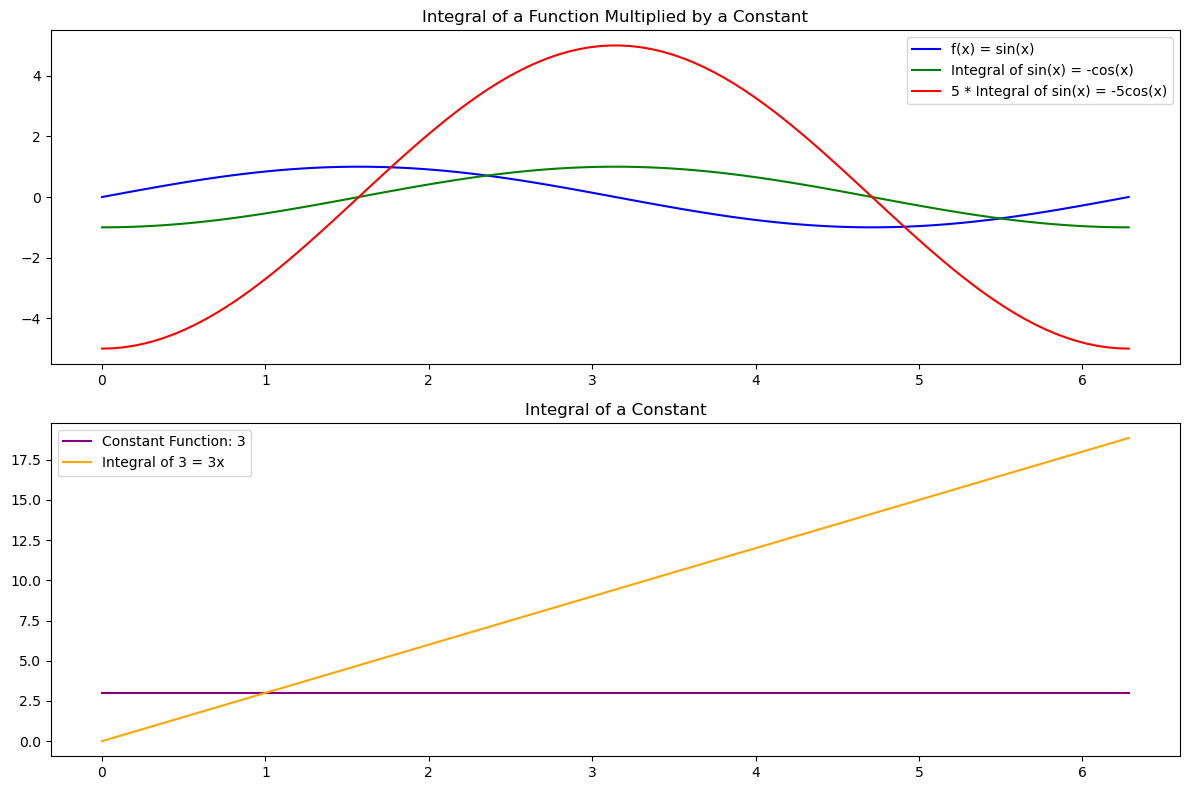

In [4]:
# Ejercicio 4
import numpy as np
import matplotlib.pyplot as plt

# Definimos el dominio
x = np.linspace(0, 2*np.pi, 100)

# Funciones a integrar
f_x = np.sin(x)  # f(x) = sin(x)
constant = 3     # Constante

# Resultados de las integrales
integral_f_x = -np.cos(x)  # Integral de sin(x) es -cos(x)
integral_constant = constant * x  # Integral de 3 es 3x

# Multiplicar la función por una constante y su integral
a = 5
integral_a_f_x = -5 * np.cos(x)  # 5 * Integral de sin(x)

# Gráficos
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(x, f_x, label='f(x) = sin(x)', color='blue')
plt.plot(x, integral_f_x, label='Integral of sin(x) = -cos(x)', color='green')
plt.plot(x, integral_a_f_x, label='5 * Integral of sin(x) = -5cos(x)', color='red')
plt.title('Integral of a Function Multiplied by a Constant')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(x, constant * np.ones_like(x), label='Constant Function: 3', color='purple')
plt.plot(x, integral_constant, label='Integral of 3 = 3x', color='orange')
plt.title('Integral of a Constant')
plt.legend()
plt.tight_layout()
plt.show()

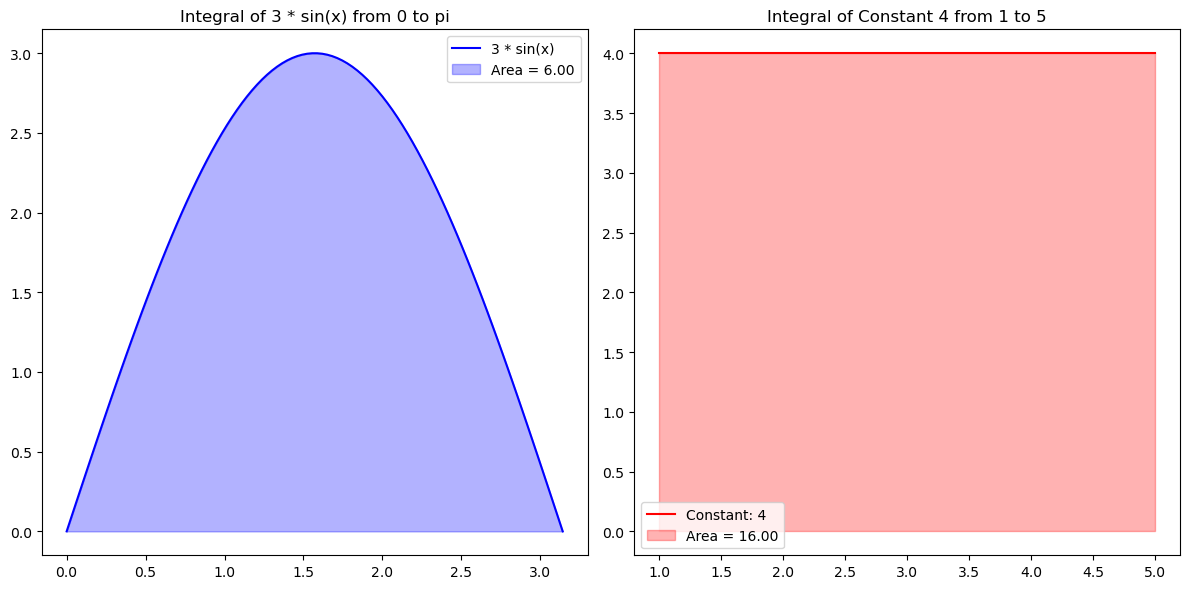

In [34]:
# Ejercicio 5
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Definimos el dominio
x = np.linspace(0, np.pi, 100)

# Funciones a integrar
f_x = np.sin(x)  # f(x) = sin(x)
a = 3  # Constante para multiplicar f(x)
b = 4  # Constante para la integral de una constante

# Integral definida de 3*sin(x) de 0 a pi
integral_a_f_x, _ = quad(lambda x: a * np.sin(x), 0, np.pi)

# Integral definida de la constante 4 de 1 a 5
integral_constant, _ = quad(lambda x: b, 1, 5)

# Gráficos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x, a * f_x, label=f'{a} * sin(x)', color='blue')
plt.fill_between(x, a * f_x, color='blue', alpha=0.3, label=f'Area = {integral_a_f_x:.2f}')
plt.title(f'Integral of {a} * sin(x) from 0 to pi')
plt.legend()

# Representación de la constante 4 y su integral
x_const = np.linspace(1, 5, 100)
y_const = b * np.ones_like(x_const)
plt.subplot(1, 2, 2)
plt.plot(x_const, y_const, label='Constant: 4', color='red')
plt.fill_between(x_const, 0, y_const, color='red', alpha=0.3, label=f'Area = {integral_constant:.2f}')
plt.title('Integral of Constant 4 from 1 to 5')
plt.legend()
plt.tight_layout()
plt.show()

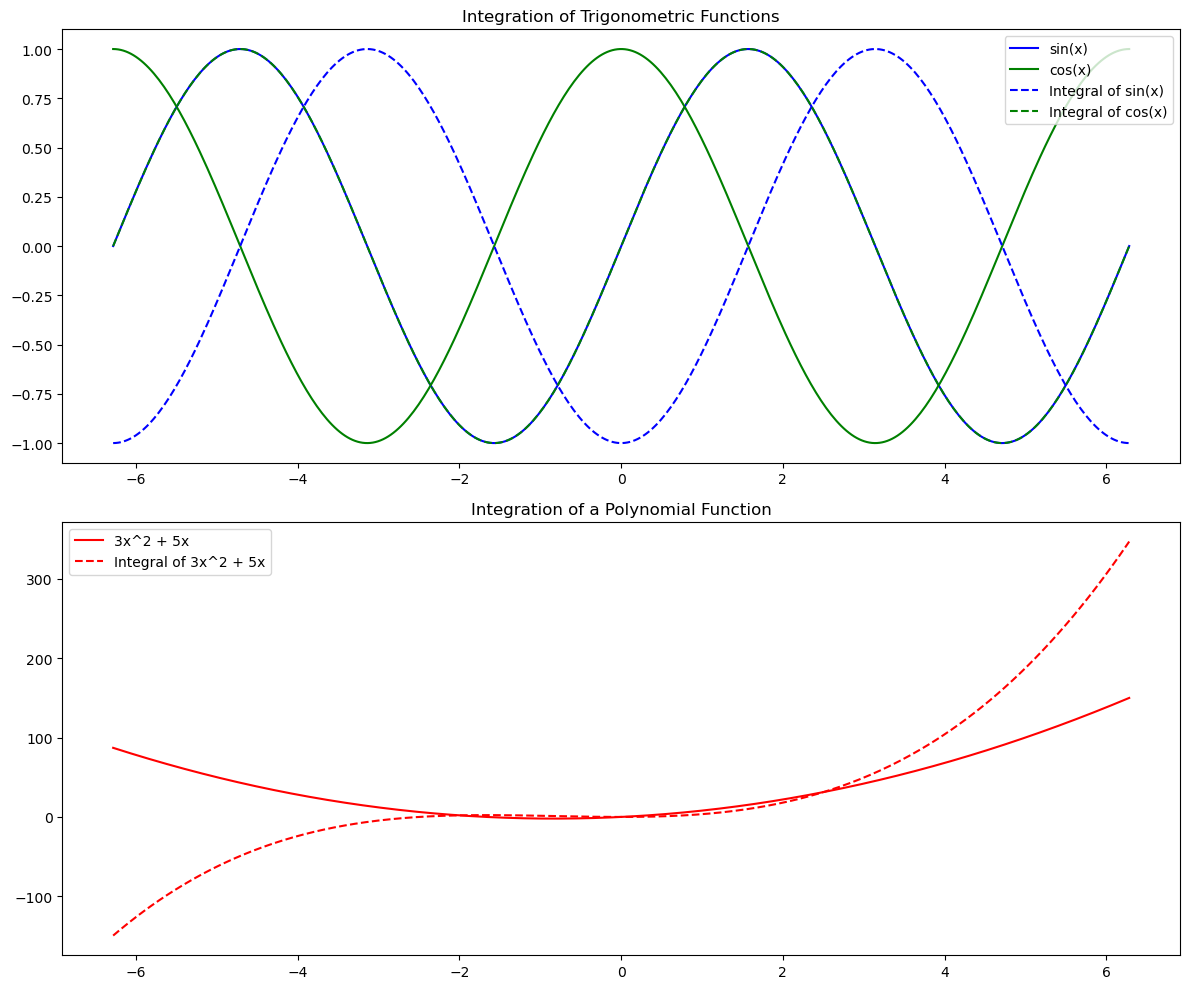

In [6]:
# Ejercicio 6
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir las funciones
f = sp.sin(x)
g = sp.cos(x)
h = 3*x**2 + 5*x

# Calcular las integrales indefinidas
integral_f = sp.integrate(f, x)
integral_g = sp.integrate(g, x)
integral_h = sp.integrate(h, x)

# Calcular la integral de la suma de funciones trigonométricas
integral_sum_trig = sp.integrate(f + g, x)

# Calcular la integral de la combinación lineal de funciones polinómicas
integral_sum_poly = sp.integrate(h, x)

# Configurar el rango para la visualización de gráficos
x_vals = np.linspace(-2*np.pi, 2*np.pi, 400)
f_vals = sp.lambdify(x, f)(x_vals)
g_vals = sp.lambdify(x, g)(x_vals)
h_vals = sp.lambdify(x, h)(x_vals)
integral_f_vals = sp.lambdify(x, integral_f)(x_vals)
integral_g_vals = sp.lambdify(x, integral_g)(x_vals)
integral_h_vals = sp.lambdify(x, integral_h)(x_vals)

# Gráficos
plt.figure(figsize=(12, 10))

# Gráfico para las funciones trigonométricas y sus integrales
plt.subplot(2, 1, 1)
plt.plot(x_vals, f_vals, label='sin(x)', color='blue')
plt.plot(x_vals, g_vals, label='cos(x)', color='green')
plt.plot(x_vals, integral_f_vals, label='Integral of sin(x)', color='blue', linestyle='dashed')
plt.plot(x_vals, integral_g_vals, label='Integral of cos(x)', color='green', linestyle='dashed')
plt.title('Integration of Trigonometric Functions')
plt.legend()

# Gráfico para la combinación lineal de funciones polinómicas y su integral
plt.subplot(2, 1, 2)
plt.plot(x_vals, h_vals, label='3x^2 + 5x', color='red')
plt.plot(x_vals, integral_h_vals, label='Integral of 3x^2 + 5x', color='red', linestyle='dashed')
plt.title('Integration of a Polynomial Function')
plt.legend()
plt.tight_layout()
plt.show()

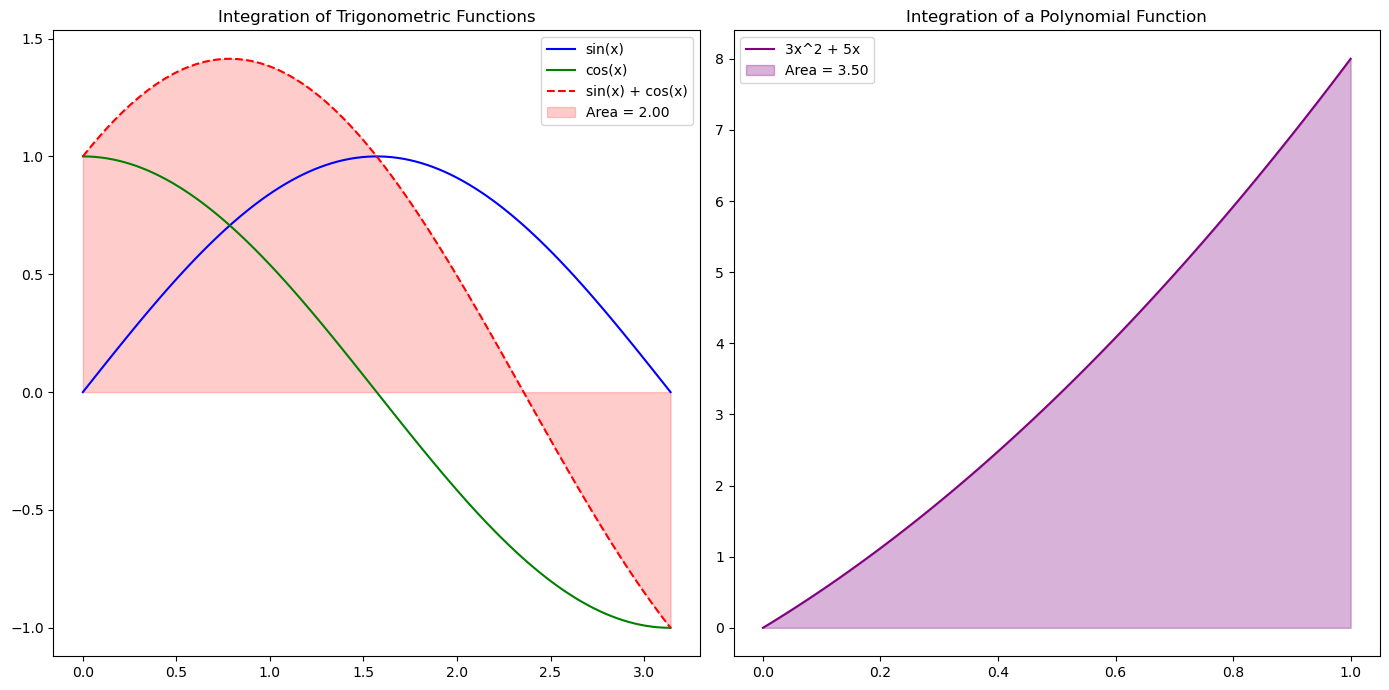

In [7]:
# Ejercicio 7
import numpy as np
import matplotlib.pyplot as plt

# Define the domain
x_vals = np.linspace(0, np.pi, 100)

# Functions and their integrals calculated from 0 to pi
sin_x = np.sin(x_vals)
cos_x = np.cos(x_vals)
sin_integral = np.trapz(sin_x, x_vals)  # Numerical integration of sin(x) from 0 to pi
cos_integral = np.trapz(cos_x, x_vals)  # Numerical integration of cos(x) from 0 to pi
sum_sin_cos = sin_x + cos_x
sum_integral = np.trapz(sum_sin_cos, x_vals)  # Numerical integration of sin(x) + cos(x) from 0 to pi

# Define the domain for the polynomial function
x_poly = np.linspace(0, 1, 100)
poly_func = 3*x_poly**2 + 5*x_poly
poly_integral = np.trapz(poly_func, x_poly)  # Numerical integration of 3x^2 + 5x from 0 to 1

# Plotting
plt.figure(figsize=(14, 7))

# Plot for trigonometric functions
plt.subplot(1, 2, 1)
plt.plot(x_vals, sin_x, label='sin(x)', color='blue')
plt.plot(x_vals, cos_x, label='cos(x)', color='green')
plt.plot(x_vals, sum_sin_cos, label='sin(x) + cos(x)', color='red', linestyle='dashed')
plt.fill_between(x_vals, 0, sum_sin_cos, color='red', alpha=0.2, label=f'Area = {sum_integral:.2f}')
plt.title('Integration of Trigonometric Functions')
plt.legend()

# Plot for polynomial function
plt.subplot(1, 2, 2)
plt.plot(x_poly, poly_func, label='3x^2 + 5x', color='purple')
plt.fill_between(x_poly, 0, poly_func, color='purple', alpha=0.3, label=f'Area = {poly_integral:.2f}')
plt.title('Integration of a Polynomial Function')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Ejercicio 8
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a integrar
f = x**3

# Calcular la integral indefinida
integral = sp.integrate(f, x)

# Mostrar el resultado
print(integral)

x**4/4


In [9]:
# Ejercicio 9
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir los límites de integración
a, b = 0, 5

# Definir la función a integrar
f = x**2

# Calcular la integral definida
integral_definida = sp.integrate(f, (x, a, b))

# Mostrar el resultado
print(integral_definida)

125/3


In [10]:
# Ejercicio 10
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la base de la función exponencial
a = 2

# Calcular la integral indefinida utilizando la regla de integración para funciones exponenciales
integral_indefinida = sp.integrate(a**x, x)

# Mostrar el resultado
print(integral_indefinida)

2**x/log(2)


In [11]:
# Ejercicio 11
import sympy as sp

# Definir la variable simbólica y los límites de integración
x = sp.symbols('x')
a, b = 1, 4

# Definir la base de la función exponencial
a_base = 3

# Calcular la integral definida utilizando la regla de integración para funciones exponenciales
integral_definida = sp.integrate(a_base**x, (x, a, b))

# Mostrar el resultado
print(integral_definida)

78/log(3)


In [12]:
# Ejercicio 12
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a integrar
f = 1/x

# Calcular la integral indefinida
integral_indefinida = sp.integrate(f, x)

# Mostrar el resultado
print(integral_indefinida)

log(x)


In [13]:
# Ejercicio 13
import sympy as sp

# Definir la variable simbólica y los límites de integración
x = sp.symbols('x')
a, b = 1, sp.exp(1)  # sp.exp(1) es el valor de e en SymPy

# Definir la función a integrar
f = 1/x

# Calcular la integral definida
integral_definida = sp.integrate(f, (x, a, b))

# Mostrar el resultado
print(integral_definida)

1


In [14]:
# Ejercicio 14
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a integrar
f = sp.sin(x)

# Calcular la integral indefinida
integral_indefinida_sin = sp.integrate(f, x)

# Mostrar el resultado
print(integral_indefinida_sin)

-cos(x)


In [15]:
# Ejercicio 15
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a integrar
f = sp.cos(x)

# Calcular la integral indefinida
integral_indefinida_cos = sp.integrate(f, x)

# Mostrar el resultado
print(integral_indefinida_cos)

sin(x)


In [16]:
# Ejercicio 16
import sympy as sp

try:
    display
except NameError:
    def display(obj):
        print(obj)
        
# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función a integrar
f = sp.tan(x)

# Calcular la integral indefinida
integral_indefinida_tan = sp.integrate(f, x)

# Mostrar el resultado
display(integral_indefinida_tan)

-log(cos(x))

In [17]:
# Ejercicio 17
import sympy as sp

x = sp.symbols('x')
f = sp.sin(x)
a, b = 0, sp.pi  # Límites de integración

integral_definida_sin = sp.integrate(f, (x, a, b))
print(integral_definida_sin)

2


### 6.4.

In [18]:
# Ejercicio 18
import sympy as sp

# Definir la variable simbólica y la función
x = sp.symbols('x')
f = (x - 2)**6

# Verificar la simplificación de la integral con el cambio de variable
u = sp.symbols('u')
f_u = u**6
integral_u = sp.integrate(f_u, u)
integral_u_substituted = integral_u.subs(u, x-2)

integral_u_substituted

(x - 2)**7/7

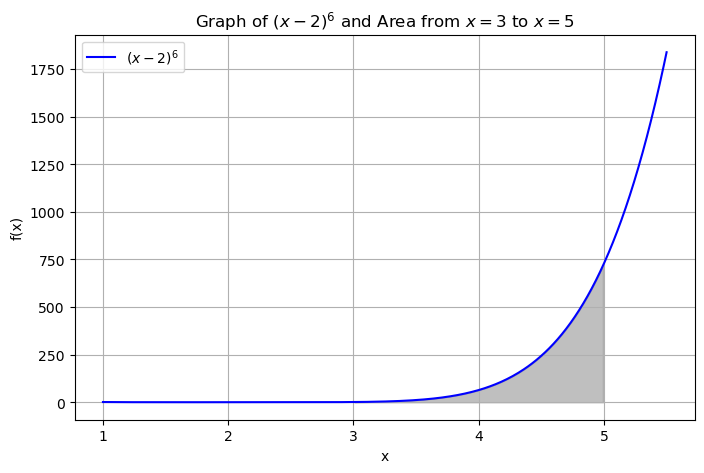

312.285714285714

In [19]:
# Ejercicio 19
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir las variables
x, u = sp.symbols('x u')

# Límites para x
a_x = 3
b_x = 5

# Límites en términos de u
a_u = a_x - 2
b_u = b_x - 2

# Integral definida en términos de u
integral_value = sp.integrate(u**6, (u, a_u, b_u))

# Crear valores para la gráfica
x_values = np.linspace(1, 5.5, 400)
function_values = (x_values - 2)**6

# Configuración de la gráfica
plt.figure(figsize=(8, 5))
plt.plot(x_values, function_values, label='$(x-2)^6$', color='blue')
plt.fill_between(x_values, function_values, where=((x_values >= 3) & (x_values <= 5)), color='gray', alpha=0.5)
plt.title('Graph of $(x-2)^6$ and Area from $x=3$ to $x=5$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.show()

# Imprimir el resultado de la integral definida
integral_value.evalf()

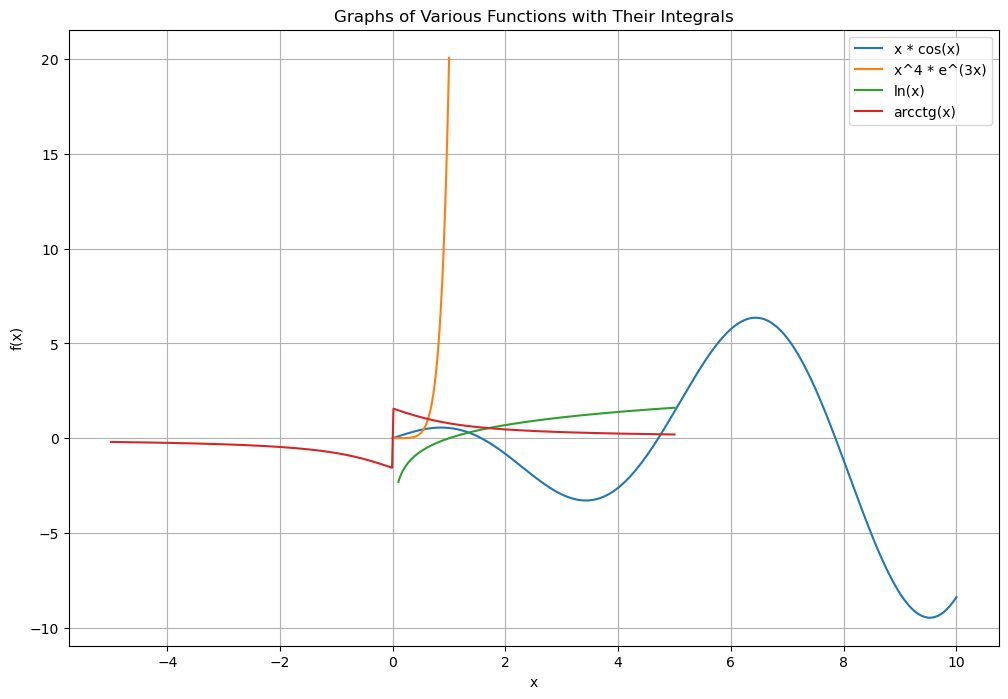

Integral of ln(x): x*log(x) - x
Integral of arcctg(x): x*acot(x) + log(x**2 + 1)/2


In [20]:
# Ejercicio 20
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la variable simbólica
x = sp.symbols('x')

# Definir funciones trigonométricas inversas que no están en numpy
def acot(x):
    return np.arctan(1/x)

# Preparar las funciones para el cálculo y la graficación
functions = [
    (x * sp.cos(x), "x * cos(x)", np.linspace(0, 10, 400)),
    (x**4 * sp.exp(3 * x), "x^4 * e^(3x)", np.linspace(0, 1, 400)),
    (sp.log(x), "ln(x)", np.linspace(0.1, 5, 400)),
    (sp.acot(x), "arcctg(x)", np.linspace(-5, 5, 400))
]

# Configurar la figura para la graficación
plt.figure(figsize=(12, 8))

# Calcular las integrales y graficar cada función
for func, label, x_vals in functions:
    
    # Evaluar y graficar usando la configuración apropiada para cada función
    if label == "arcctg(x)":
        func_np = sp.lambdify(x, func, {"acot": acot})
    else:
        func_np = sp.lambdify(x, func, "numpy")
    y_values = func_np(x_vals)
    
    # Graficar
    plt.plot(x_vals, y_values, label=f'{label}')
    
    # Integración por partes (simbólicamente, mostrando sólo el resultado para demostración)
    u = func.args[0] if len(func.args) > 0 else func
    dv = func.args[1] if len(func.args) > 1 else 1
    v = sp.integrate(dv, x)
    integral = sp.integrate(u * dv, x)
    integral_simplified = sp.simplify(integral)

# Añadir títulos y configuración a la gráfica
plt.title('Graphs of Various Functions with Their Integrals')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

# Corrección de las integrales específicas
integral_ln_x = sp.integrate(sp.log(x), x)
integral_acot_x = sp.integrate(sp.acot(x), x)

# Imprimir las integrales corregidas
print("Integral of ln(x):", integral_ln_x)
print("Integral of arcctg(x):", integral_acot_x)

In [21]:
# Ejercicio 21
import sympy as sp

# Definir la variable simbólica x y una constante a
x, a = sp.symbols('x a')

# Integral de (g'(x) / g(x))
g = x**2 + 1  # Definir la función g(x)
g_prime = sp.diff(g, x)  # Derivar g(x) para obtener g'(x)
integral_1 = sp.integrate(g_prime / g, x)  # Calcular la integral

# Ejemplo 2: Integral de 1 / (x^2 + a^2)
integral_2 = sp.integrate(1 / (x**2 + a**2), x)  # Calcular la integral

# Imprimir resultados
print("Integral de (g'(x) / g(x)):")
print(sp.simplify(integral_1))
print("\nIntegral de 1 / (x^2 + a^2):")
print(sp.simplify(integral_2))

Integral de (g'(x) / g(x)):
log(x**2 + 1)

Integral de 1 / (x^2 + a^2):
I*(-log(-I*a + x) + log(I*a + x))/(2*a)


Descomposición en fracciones parciales: 2/(x**2 + 1) + 1/(x + 1)
Integral de la descomposición: log(x + 1) + 2*atan(x)


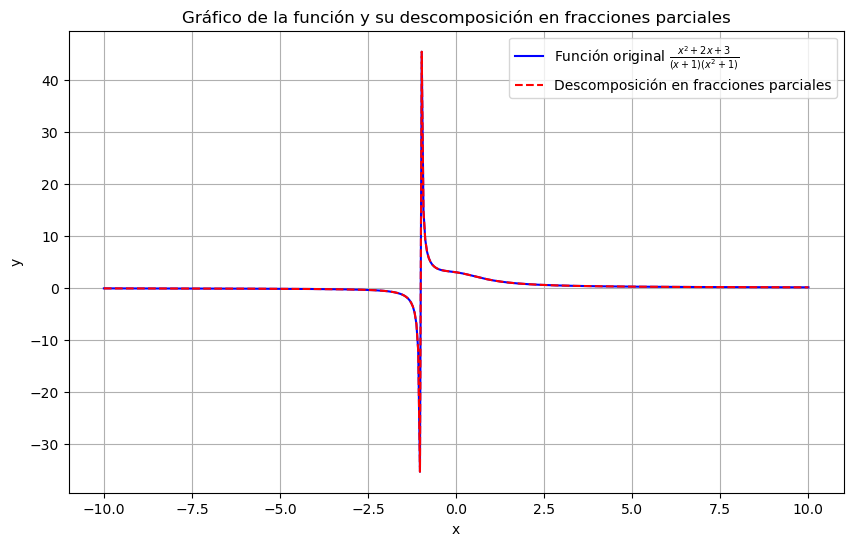

In [22]:
# Ejercicio 22
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica y constantes
x = sp.symbols('x')
A, B, C = sp.symbols('A B C')

# Definir la función original
f = (x**2 + 2*x + 3)/((x+1)*(x**2 + 1))

# Realizar la descomposición en fracciones parciales
decomposition = sp.apart(f)

# Calcular las integrales de cada término
integral_decomposed = sp.integrate(decomposition, x)

# Mostrar la descomposición y las integrales
print("Descomposición en fracciones parciales:", decomposition)
print("Integral de la descomposición:", integral_decomposed)

# Función para evaluar expresiones de sympy
def eval_expr(expr, values):
    return np.array([float(expr.subs(x, v)) for v in values])

# Generar valores para x
x_vals = np.linspace(-10, 10, 400)
original_vals = eval_expr(f, x_vals)
decomposed_vals = eval_expr(decomposition, x_vals)

# Graficar la función original y la descomposición
plt.figure(figsize=(10, 6))
plt.plot(x_vals, original_vals, label='Función original $\\frac{x^2 + 2x + 3}{(x+1)(x^2 + 1)}$', color='blue')
plt.plot(x_vals, decomposed_vals, label='Descomposición en fracciones parciales', color='red', linestyle='--')
plt.title('Gráfico de la función y su descomposición en fracciones parciales')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Integral definida desde x = -2 hasta x = 2: nan


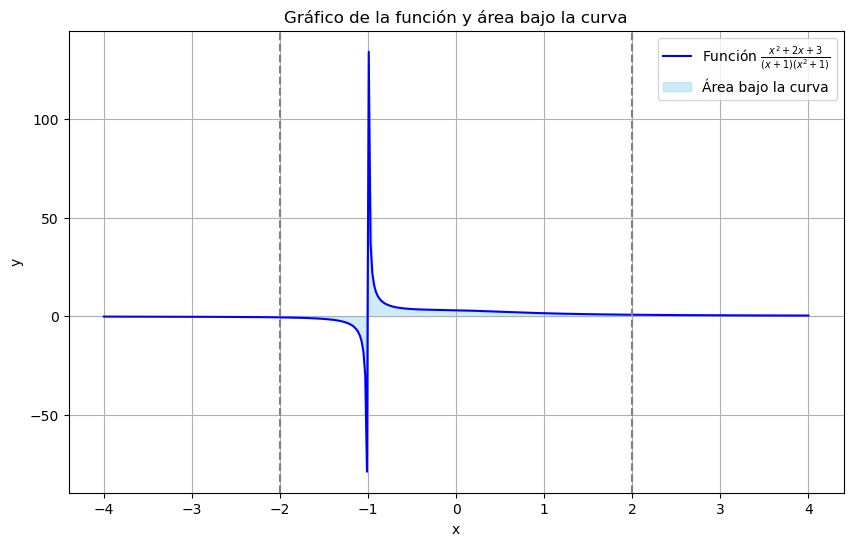

In [23]:
# Ejercicio 23
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función original
f = (x**2 + 2*x + 3)/((x+1)*(x**2 + 1))

# Realizar la descomposición en fracciones parciales
decomposition = sp.apart(f)

# Calcular la integral definida de la descomposición
a, b = -2, 2  # Límites de integración
integral_definida = sp.integrate(decomposition, (x, a, b))

# Mostrar la integral definida
print("Integral definida desde x = -2 hasta x = 2:", integral_definida)

# Función para evaluar expresiones de sympy
def eval_expr(expr, values):
    return np.array([float(expr.subs(x, v)) for v in values])

# Generar valores para x y evaluar la función
x_vals = np.linspace(-4, 4, 400)
y_vals = eval_expr(f, x_vals)

# Generar valores para el área bajo la curva
x_fill = np.linspace(a, b, 100)
y_fill = eval_expr(f, x_fill)

# Graficar la función y el área bajo la curva
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Función $\\frac{x^2 + 2x + 3}{(x+1)(x^2 + 1)}$', color='blue')
plt.fill_between(x_fill, y_fill, color='skyblue', alpha=0.4, label='Área bajo la curva')
plt.title('Gráfico de la función y área bajo la curva')
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(x=a, color='grey', linestyle='--')
plt.axvline(x=b, color='grey', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

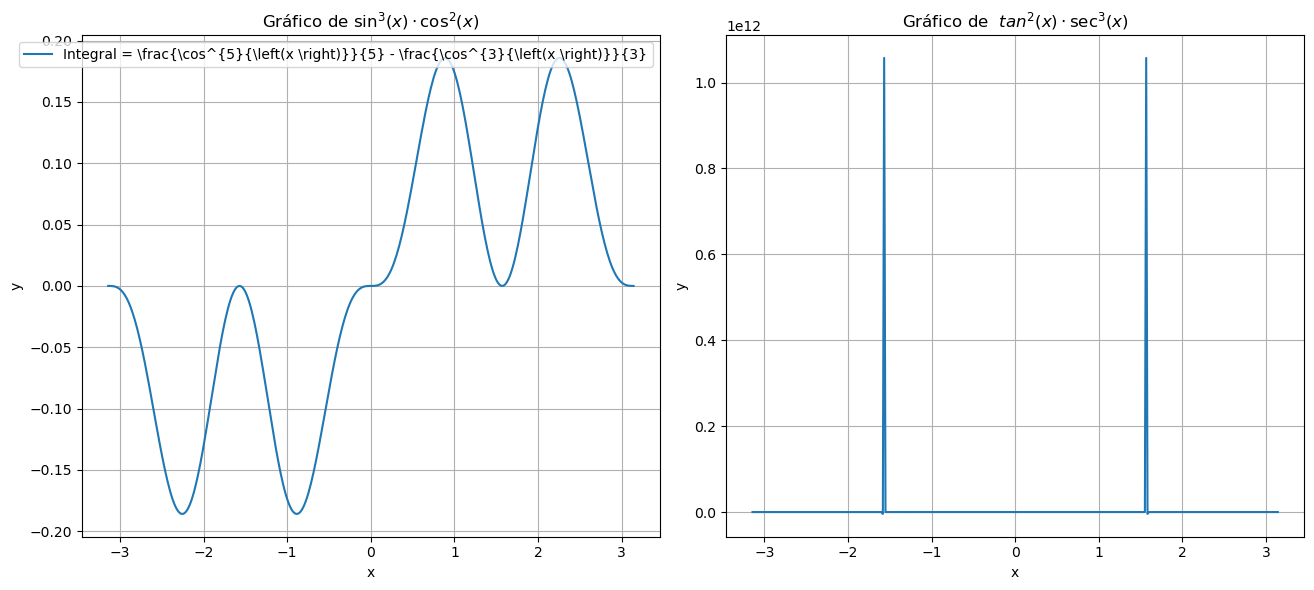

In [24]:
# Ejercicio 24
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica
x = sp.symbols('x')

# Ejemplo 1: Integral de sin^3(x) * cos^2(x)
# Función a integrar
f1 = sp.sin(x)**3 * sp.cos(x)**2

# Calcular la integral indefinida
integral1 = sp.integrate(f1, x)

# Ejemplo 2: Integral de tan^2(x) * sec^3(x)
# Función a integrar
f2 = sp.tan(x)**2 * sp.sec(x)**3

# Calcular la integral indefinida
integral2 = sp.integrate(f2, x)

# Función para evaluar expresiones de sympy
def eval_expr(expr, values):
    return np.array([float(expr.subs(x, v)) for v in values])

# Rango de valores para x
x_vals = np.linspace(-np.pi, np.pi, 400)
y_vals1 = eval_expr(f1, x_vals)
y_vals2 = eval_expr(f2, x_vals)

# Crear gráficos
plt.figure(figsize=(14, 6))

# Gráfico para sin^3(x) * cos^2(x)
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals1, label=f'Integral = {sp.latex(integral1)}')
plt.title('Gráfico de $\sin^3(x) \cdot \cos^2(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Gráfico para tan^2(x) * sec^3(x)
plt.subplot(1, 2, 2)
plt.plot(x_vals, y_vals2, label=f'Integral = {sp.latex(integral2)}')
plt.title('Gráfico de $\ tan^2(x) \cdot \sec^3(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.tight_layout()
plt.show()

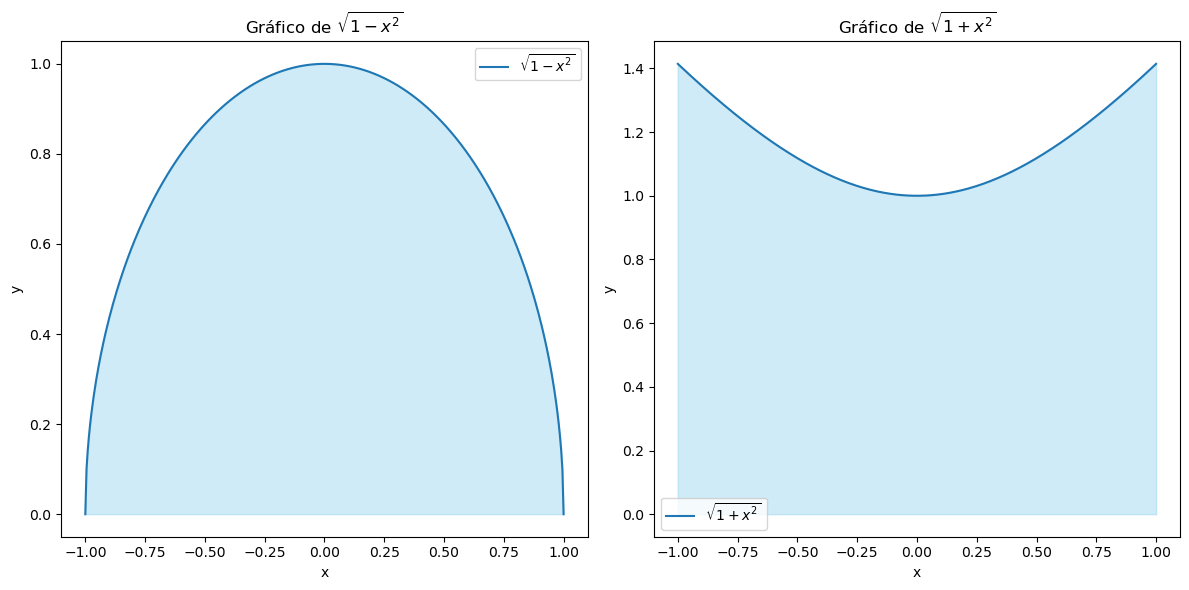

In [25]:
# Ejercicio 25
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica y parámetros
x, a, theta = sp.symbols('x a theta')

# Ejemplo 1: Sustitución para sqrt(a^2 - x^2)
# Sustitución y diferencial
x1 = a * sp.sin(theta)
dx1 = sp.diff(x1, theta)

# Función original y transformada
f1_original = sp.sqrt(a**2 - x**2)
f1_transformed = sp.sqrt(a**2 - x1**2).subs(x, x1) * dx1

# Integral transformada
integral1 = sp.integrate(f1_transformed, (theta, -sp.pi/2, sp.pi/2))

# Ejemplo 2: Sustitución para sqrt(a^2 + x^2)
# Sustitución y diferencial
x2 = a * sp.tan(theta)
dx2 = sp.diff(x2, theta)

# Función original y transformada
f2_original = sp.sqrt(a**2 + x**2)
f2_transformed = sp.sqrt(a**2 + x2**2).subs(x, x2) * dx2

# Integral transformada
integral2 = sp.integrate(f2_transformed, (theta, -sp.pi/2, sp.pi/2))

# Evaluar funciones para graficar
def eval_expr(expr, values, param=a):
    return np.array([float(expr.subs([(x, v), (a, 1)])) for v in values])

# Valores de x para gráficos
x_vals = np.linspace(-1, 1, 400)
y_vals1 = eval_expr(f1_original, x_vals)
y_vals2 = eval_expr(f2_original, x_vals)

# Crear gráficos
plt.figure(figsize=(12, 6))

# Gráfico para sqrt(a^2 - x^2)
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals1, label='$\sqrt{{1 - x^2}}$')
plt.fill_between(x_vals, y_vals1, color='skyblue', alpha=0.4)
plt.title('Gráfico de $\sqrt{1 - x^2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Gráfico para sqrt(a^2 + x^2)
plt.subplot(1, 2, 2)
plt.plot(x_vals, y_vals2, label='$\sqrt{{1 + x^2}}$')
plt.fill_between(x_vals, y_vals2, color='skyblue', alpha=0.4)
plt.title('Gráfico de $\sqrt{1 + x^2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

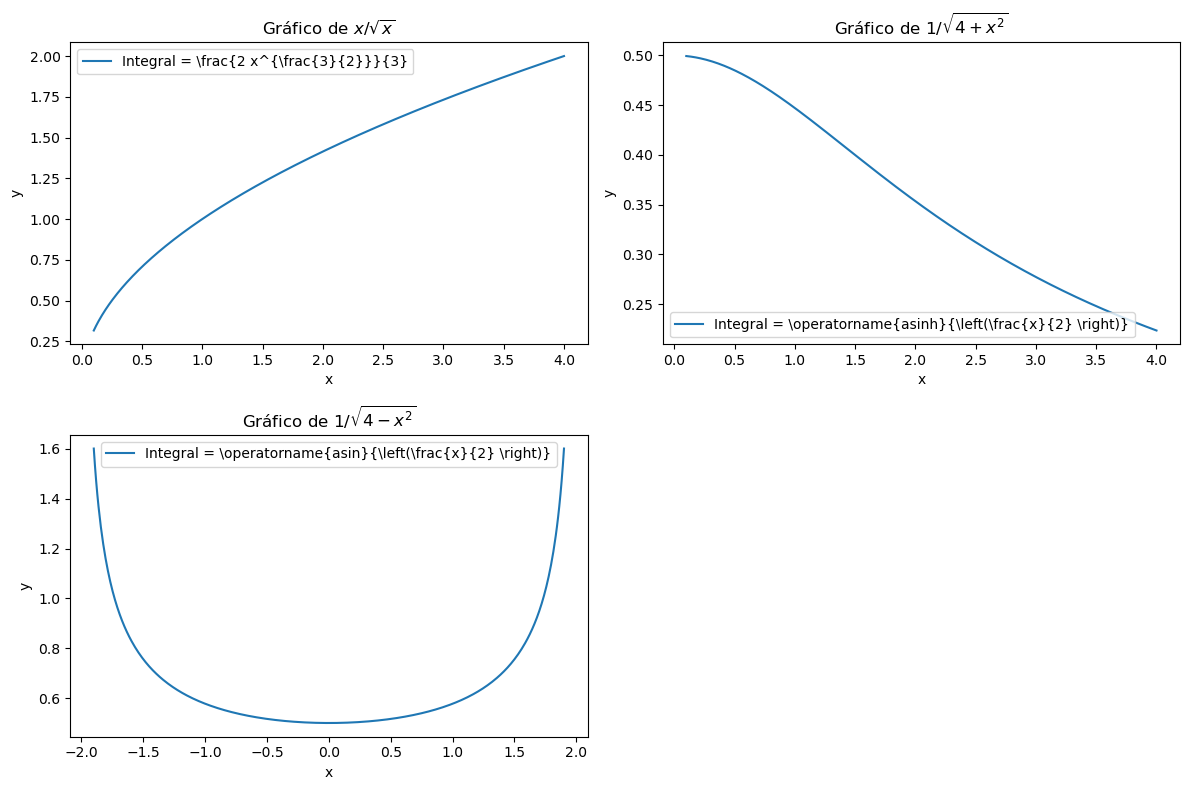

In [26]:
# Ejercicio 26
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica
x = sp.symbols('x')

# Ejemplo 1: Integral de x/sqrt(x)
f1 = x / sp.sqrt(x)
integral1 = sp.integrate(f1, x)

# Ejemplo 2: Integral de 1/sqrt(4 + x^2)
f2 = 1 / sp.sqrt(4 + x**2)
integral2 = sp.integrate(f2, x)

# Ejemplo 3: Integral de 1/sqrt(4 - x^2)
f3 = 1 / sp.sqrt(4 - x**2)
integral3 = sp.integrate(f3, x)

# Función para evaluar expresiones de sympy
def eval_expr(expr, values):
    return np.array([float(expr.subs(x, v)) for v in values])

# Rango de valores para x
x_vals = np.linspace(0.1, 4, 400)  # Ajustado para evitar divisiones por cero
y_vals1 = eval_expr(f1, x_vals)
y_vals2 = eval_expr(f2, x_vals)
x_vals3 = np.linspace(-1.9, 1.9, 400)  # Limitado para evitar valores fuera del dominio
y_vals3 = eval_expr(f3, x_vals3)

# Crear gráficos
plt.figure(figsize=(12, 8))

# Gráfico para x/sqrt(x)
plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals1, label=f'Integral = {sp.latex(integral1)}')
plt.title('Gráfico de $x/\\sqrt{x}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Gráfico para 1/sqrt(4 + x^2)
plt.subplot(2, 2, 2)
plt.plot(x_vals, y_vals2, label=f'Integral = {sp.latex(integral2)}')
plt.title('Gráfico de $1/\\sqrt{4 + x^2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Gráfico para 1/sqrt(4 - x^2)
plt.subplot(2, 2, 3)
plt.plot(x_vals3, y_vals3, label=f'Integral = {sp.latex(integral3)}')
plt.title('Gráfico de $1/\\sqrt{4 - x^2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

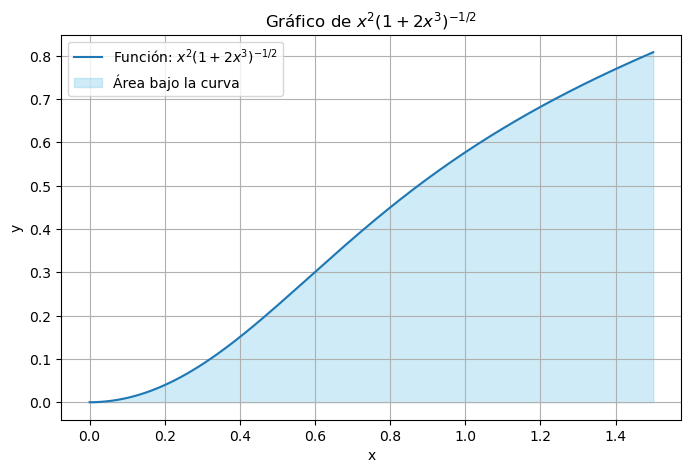

In [27]:
# Ejercicio 27
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica y parámetros adicionales
x, u = sp.symbols('x u')

# Definir la función original
f = x**2 * (1 + 2*x**3)**(-sp.Rational(1, 2))

# Cambio de variable sugerido: u = x**3
# Sustituir x = u**(1/3) en la función y calcular dx
x_sub = u**(sp.Rational(1, 3))
dx = sp.diff(x_sub, u)

# Sustituir en la función original
f_sub = f.subs(x, x_sub) * dx

# Calcular la integral en términos de u
integral_u = sp.integrate(f_sub.simplify(), u)

# Simplificar la integral (opcional, dependiendo de la complejidad)
simplified_integral = sp.simplify(integral_u)

# Evaluar la integral resultante en términos de x
integral_result = simplified_integral.subs(u, x**3)

# Función para evaluar expresiones de sympy
def eval_expr(expr, values):
    return np.array([float(expr.subs(x, v)) for v in values])

# Rango de valores para x
x_vals = np.linspace(0, 1.5, 400)  # Ajustado para evitar problemas en el dominio
y_vals = eval_expr(f, x_vals)

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='Función: $x^2 (1 + 2x^3)^{-1/2}$')
plt.fill_between(x_vals, y_vals, color='skyblue', alpha=0.4, label='Área bajo la curva')
plt.title('Gráfico de $x^2 (1 + 2x^3)^{-1/2}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### 6.5. 

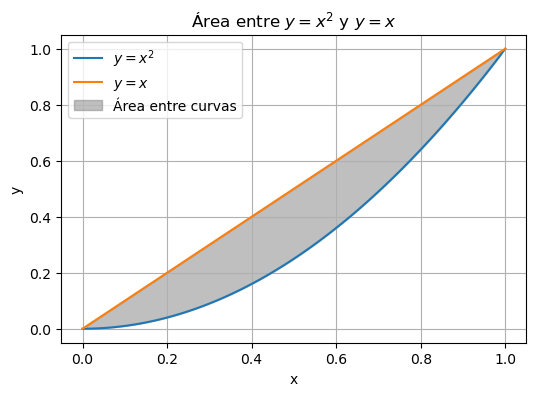

El área entre las curvas es: 0.166666666666667


In [28]:
# Ejercicio 28
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica
x = sp.symbols('x')

# Definir las funciones
f = x**2
g = x

# Calcula la integral de la diferencia entre las funciones
area = sp.integrate(g - f, (x, 0, 1))

# Evaluar las funciones para el gráfico
x_vals = np.linspace(0, 1, 100)
f_vals = np.array([f.subs(x, val) for val in x_vals], dtype=float)
g_vals = np.array([g.subs(x, val) for val in x_vals], dtype=float)

# Crear el gráfico
plt.figure(figsize=(6, 4))
plt.plot(x_vals, f_vals, label='$y=x^2$')
plt.plot(x_vals, g_vals, label='$y=x$')
plt.fill_between(x_vals, f_vals, g_vals, where=(g_vals > f_vals), color='gray', alpha=0.5, label='Área entre curvas')
plt.title('Área entre $y=x^2$ y $y=x$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"El área entre las curvas es: {area.evalf()}")

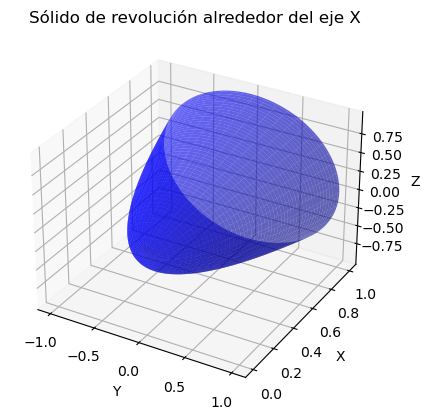

El volumen del sólido de revolución es: 0.418879020478639


In [29]:
# Ejercicio 29
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica
x = sp.symbols('x')

# Definir las funciones
f = x**2  # y = x^2
g = x     # y = x

# Definir las funciones para el volumen (método del disco)
volume = sp.pi * sp.integrate((g**2 - f**2), (x, 0, 1))

# Preparar datos para el gráfico del sólido de revolución
x_vals = np.linspace(0, 1, 100)  # Valores de x entre 0 y 1
theta_vals = np.linspace(0, 2 * np.pi, 100)  # Valores de theta para una revolución completa
X, T = np.meshgrid(x_vals, theta_vals)  # Crear malla de valores
Y = np.sqrt(X) * np.cos(T)  # Calcular Y en coordenadas cilíndricas
Z = np.sqrt(X) * np.sin(T)  # Calcular Z en coordenadas cilíndricas

# Configuración del gráfico 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Y, X, Z, color='b', alpha=0.6)
ax.set_title('Sólido de revolución alrededor del eje X')
ax.set_xlabel('Y')
ax.set_ylabel('X')
ax.set_zlabel('Z')
plt.show()

# Imprimir el volumen calculado del sólido de revolución
print(f"El volumen del sólido de revolución es: {volume.evalf()}")

In [30]:
# Ejercicio 30
import sympy as sp

# Definir variables simbólicas
x, a, b = sp.symbols('x a b')

# Suponer una función f(x) que dependa de 'a' y 'b'
f = a * x**2 + b

# Calcular el diferencial de la función
df = sp.diff(f, x)

# Expresión para la longitud de arco desde x=0 a x=1 (modificar según sea necesario)
arc_length = sp.integrate(sp.sqrt(1 + df**2), (x, 0, 1))

# Suponemos valores para a y b por defecto
a_value = 1
b_value = 0

# Sustituimos a y b en la expresión y evaluamos numéricamente
numerical_length = sp.N(arc_length.subs({a: a_value, b: b_value}))

# Imprimir el resultado de la longitud de arco evaluada numéricamente
print("Longitud de arco numérica:", numerical_length)

Longitud de arco numérica: 1.47894285754460


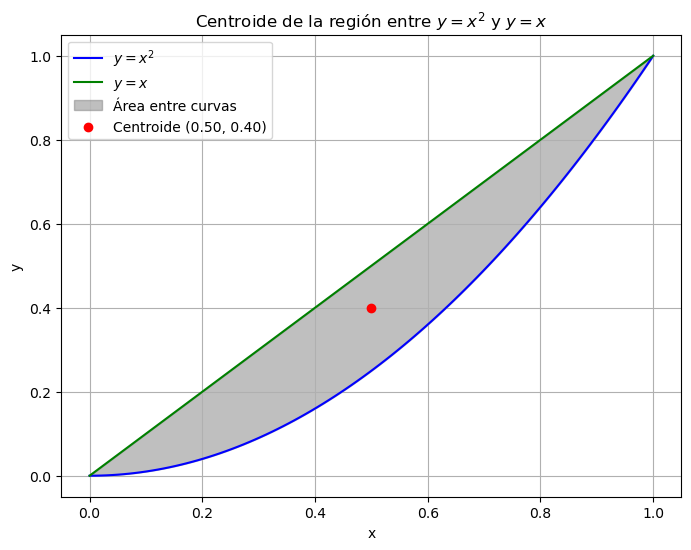

Área de la región: -0.166666666666667
Coordenada x del centroide: 0.500000000000000
Coordenada y del centroide: 0.400000000000000


In [31]:
# Ejercicio 31
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir la variable simbólica y las funciones
x = sp.symbols('x')
f = x**2  # Curva superior
g = x     # Curva inferior

# Calcular el área entre las curvas
area = sp.integrate(f - g, (x, 0, 1))

# Calcular las coordenadas del centroide
x_bar = 1 / area * sp.integrate(x * (f - g), (x, 0, 1))
y_bar = 1 / (2 * area) * sp.integrate((f**2 - g**2), (x, 0, 1))

# Evaluar las expresiones
area = area.evalf()
x_bar = x_bar.evalf()
y_bar = y_bar.evalf()

# Función para evaluar las curvas para graficar
x_vals = np.linspace(0, 1, 100)
f_vals = np.array([f.subs(x, val) for val in x_vals], dtype=float)
g_vals = np.array([g.subs(x, val) for val in x_vals], dtype=float)

# Crear gráfico
plt.figure(figsize=(8, 6))
plt.plot(x_vals, f_vals, label='$y=x^2$', color='blue')
plt.plot(x_vals, g_vals, label='$y=x$', color='green')
plt.fill_between(x_vals, f_vals, g_vals, color='gray', alpha=0.5, label='Área entre curvas')
plt.scatter([x_bar], [y_bar], color='red', zorder=5, label=f'Centroide ({x_bar:.2f}, {y_bar:.2f})')
plt.title('Centroide de la región entre $y=x^2$ y $y=x$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Imprimir los resultados del cálculo
print(f"Área de la región: {area}")
print(f"Coordenada x del centroide: {x_bar}")
print(f"Coordenada y del centroide: {y_bar}")

### FIN